In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

In [2]:
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S


In [6]:
df["Age"].sort_values()

803    0.42
755    0.67
644    0.75
469    0.75
78     0.83
       ... 
859     NaN
863     NaN
868     NaN
878     NaN
888     NaN
Name: Age, Length: 891, dtype: float64

In [8]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [9]:
df["Age"].sort_values()

803     0.42
755     0.67
469     0.75
644     0.75
78      0.83
       ...  
116    70.50
493    71.00
96     71.00
851    74.00
630    80.00
Name: Age, Length: 891, dtype: float64

In [10]:
sorted_age = df["Age"].sort_values()

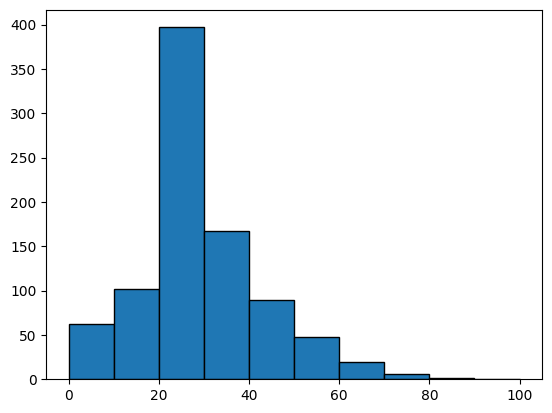

In [13]:
plt.hist(sorted_age, edgecolor = "black", bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
plt.show()

In [14]:
df.loc[df["Survived"] == 1,"Age"].sort_values()

803     0.42
755     0.67
644     0.75
469     0.75
78      0.83
       ...  
570    62.00
829    62.00
483    63.00
275    63.00
630    80.00
Name: Age, Length: 342, dtype: float64

In [15]:
survived_age = df.loc[df["Survived"] == 1,"Age"].sort_values()

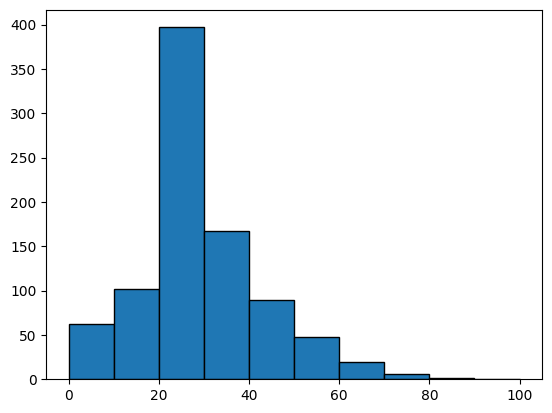

In [16]:
plt.hist(sorted_age, edgecolor = "black", bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
plt.show()

In [18]:
pd.cut(df["Age"], bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]).sort_values()

445     (0, 10]
480     (0, 10]
479     (0, 10]
469     (0, 10]
119     (0, 10]
         ...   
116    (70, 80]
630    (70, 80]
851    (70, 80]
96     (70, 80]
493    (70, 80]
Name: Age, Length: 891, dtype: category
Categories (10, interval[int64, right]): [(0, 10] < (10, 20] < (20, 30] < (30, 40] ... (60, 70] < (70, 80] < (80, 90] < (90, 100]]

In [20]:
age_bins = pd.cut(df["Age"], bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

In [29]:
((df.groupby(age_bins)["Survived"].mean().round(2))*100).fillna(0)

C:\Users\AAYUSH OJHA\AppData\Local\Temp\ipykernel_13676\159186764.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ((df.groupby(age_bins)["Survived"].mean().round(2))*100).fillna(0)


Age
(0, 10]      59.0
(10, 20]     38.0
(20, 30]     33.0
(30, 40]     45.0
(40, 50]     38.0
(50, 60]     40.0
(60, 70]     24.0
(70, 80]     20.0
(80, 90]      0.0
(90, 100]     0.0
Name: Survived, dtype: float64

In [30]:
survived_by_age = ((df.groupby(age_bins)["Survived"].mean().round(2))*100).fillna(0)

C:\Users\AAYUSH OJHA\AppData\Local\Temp\ipykernel_13676\4168270799.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survived_by_age = ((df.groupby(age_bins)["Survived"].mean().round(2))*100).fillna(0)


In [34]:
# plt.bar(survived_by_age.index, survived_by_age.values)
# plt.show()

# is giving error because:
# our data became categorical when we did groupby(), and hist doesn't work on the cayegorical data

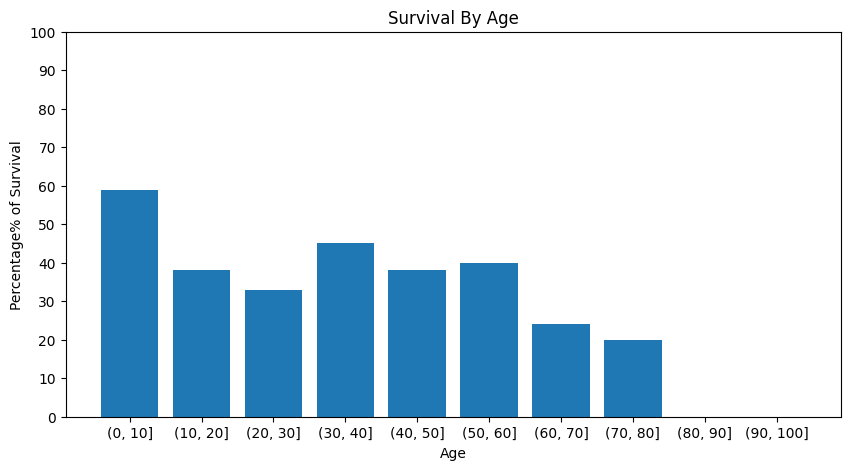

In [38]:
plt.figure(figsize=(10,5))
plt.bar(survived_by_age.index.astype(str), survived_by_age.values)
plt.yticks(np.arange(0, 101, 10))
plt.xlabel("Age")
plt.ylabel("Percentage% of Survival")
plt.title("Survival By Age")
plt.show()

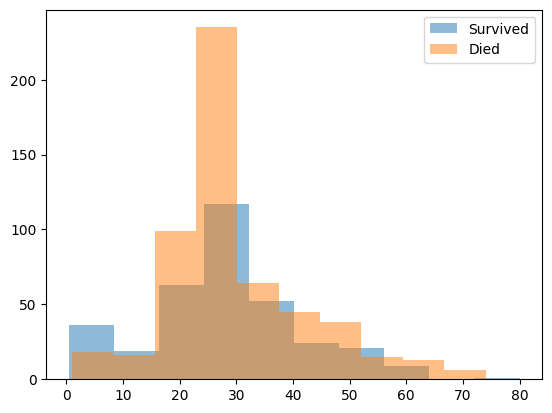

In [39]:
plt.hist(df[df["Survived"]==1]["Age"], alpha=0.5, label="Survived")
plt.hist(df[df["Survived"]==0]["Age"], alpha=0.5, label="Died")

plt.legend()